# Análise de Sentimentos em Avaliações de Produtos
## Módulo 1 - Mestrado

**Filme:** O Agente Secreto (IMDB)  
**Classificação ternária:** Negativo (1-4), Neutro (5-6), Positivo (7-10)

In [ ]:
%pip install pandas numpy matplotlib sklearn seaborn requests bs4 lxml

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

ModuleNotFoundError: No module named 'matplotlib'

## 1. Carregamento e Exploração dos Dados

In [ ]:
df = pd.read_csv('reviews_tt0111161.csv')
print(f"Total de reviews: {len(df)}")
print(f"Reviews com rating: {df['rating'].notna().sum()}")
print(f"Reviews com texto: {(df['text'].str.len() > 0).sum()}")
df.head()

Total de reviews: 109
Reviews com rating: 104
Reviews com texto: 109


,rating,title,text,date,author
0,5.0,Disappointing & Boring,Only decided to watch the movie because the ma...,2026-01-31,HighlanderABC
1,7.0,A Film of Exceptional Form and Unresolved Meaning,The Secret Agent is a film that immediately co...,2026-01-31,mehdimellatdoust
2,10.0,A Listening Film in an Age of Noise,"O Agente Secreto, directed by Kleber Mendonça ...",2026-01-31,luis-boaventura22
3,1.0,My review got deleted! Why?,"I'm Brazilian, politically on the left and a f...",2026-01-30,Freethinker_Atheist
4,5.0,Leggless and Pointless for me,My Review- The Secret Agent\nIn Cinemas now\nM...,2026-01-30,tm-sheehan


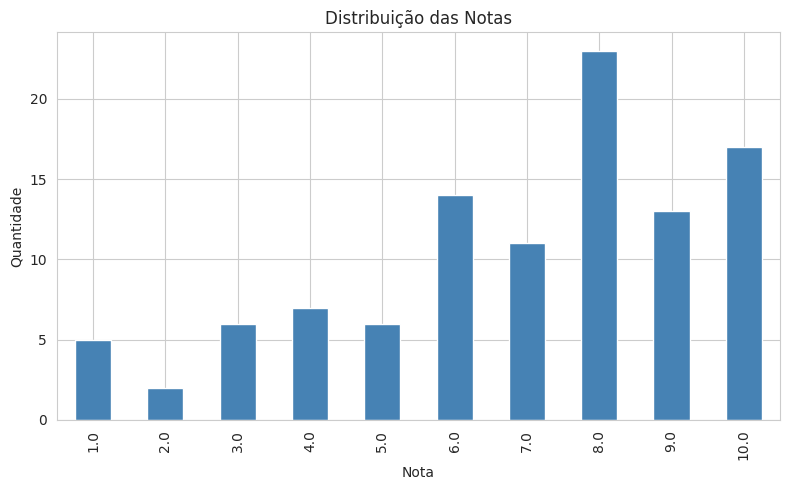

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
df['rating'].value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Nota')
ax.set_ylabel('Quantidade')
ax.set_title('Distribuição das Notas')
plt.tight_layout()
plt.show()

## 2. Pré-processamento

**Esquema de labels (ternário):**
- **Negativo:** notas 1-4
- **Neutro:** notas 5-6
- **Positivo:** notas 7-10

Distribuição dos sentimentos:
sentiment
Positivo    64
Neutro      20
Negativo    20
Name: count, dtype: int64

Total: 104 reviews


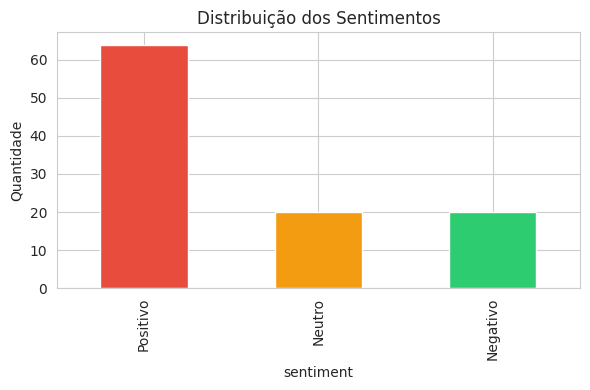

In [4]:
# Remover reviews sem rating
df = df[df['rating'].notna()].copy()

# Atribuir labels
def assign_label(rating):
    if rating <= 4:
        return 'Negativo'
    elif rating <= 6:
        return 'Neutro'
    else:
        return 'Positivo'

df['sentiment'] = df['rating'].apply(assign_label)

print("Distribuição dos sentimentos:")
print(df['sentiment'].value_counts())
print(f"\nTotal: {len(df)} reviews")

fig, ax = plt.subplots(figsize=(6, 4))
df['sentiment'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c', '#f39c12', '#2ecc71'])
ax.set_title('Distribuição dos Sentimentos')
ax.set_ylabel('Quantidade')
plt.tight_layout()
plt.show()

In [5]:
import re
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-záàâãéèêíïóôõöúüçñ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df['text_clean'] = df['text'].apply(preprocess_text)

print("Exemplo de texto original:")
print(df['text'].iloc[0][:200])
print("\nTexto pré-processado:")
print(df['text_clean'].iloc[0][:200])

Exemplo de texto original:
Only decided to watch the movie because the main actor used to have a pretty good role in the TV series Narcos not that long ago. But the storyline and directing of this movie is very disappointing. I

Texto pré-processado:
decided watch movie main actor used pretty good role series narcos long ago storyline directing movie disappointing watched first minutes continue anymore confused story movie going lots random pieces


In [6]:
X = df['text_clean']
y = df['sentiment']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTreino: {len(X_train)} | Teste: {len(X_test)}")
print(f"Distribuição treino: {np.bincount(y_train)}")
print(f"Distribuição teste:  {np.bincount(y_test)}")

Classes: ['Negativo' 'Neutro' 'Positivo']

Treino: 83 | Teste: 21
Distribuição treino: [16 16 51]
Distribuição teste:  [ 4  4 13]


## 3. Classificador 1: SVM + Bag of Words (TF-IDF)

In [7]:
# Vetorização TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# SVM
svm_bow = SVC(kernel='linear', C=1.0, random_state=42)
svm_bow.fit(X_train_tfidf, y_train)

y_pred_bow = svm_bow.predict(X_test_tfidf)

print("=== SVM + TF-IDF (Bag of Words) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_bow):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_bow, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_bow, average='weighted'):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_bow, target_names=le.classes_))

=== SVM + TF-IDF (Bag of Words) ===
Acurácia: 0.6190
F1 (macro): 0.2549
F1 (weighted): 0.4734

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.00      0.00      0.00         4
      Neutro       0.00      0.00      0.00         4
    Positivo       0.62      1.00      0.76        13

    accuracy                           0.62        21
   macro avg       0.21      0.33      0.25        21
weighted avg       0.38      0.62      0.47        21



## 4. Classificador 2: SVM + Embeddings (Sentence-BERT)

In [8]:
from sentence_transformers import SentenceTransformer

# Usar sentence-transformers para gerar embeddings
model_emb = SentenceTransformer('all-MiniLM-L6-v2')

# Embeddings sobre o texto original (não pré-processado) para melhor representação semântica
print("Gerando embeddings...")
X_train_emb = model_emb.encode(X_train.tolist(), show_progress_bar=True)
X_test_emb = model_emb.encode(X_test.tolist(), show_progress_bar=True)
print(f"Shape embeddings: {X_train_emb.shape}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 515.90it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gerando embeddings...


Batches: 100%|██████████| 1/1 [00:00<00:00,  2.24it/s]

Shape embeddings: (83, 384)


In [9]:
# SVM sobre embeddings
svm_emb = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_emb.fit(X_train_emb, y_train)

y_pred_emb = svm_emb.predict(X_test_emb)

print("=== SVM + Sentence Embeddings ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_emb):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_emb, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_emb, average='weighted'):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_emb, target_names=le.classes_))

=== SVM + Sentence Embeddings ===
Acurácia: 0.6190
F1 (macro): 0.2549
F1 (weighted): 0.4734

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.00      0.00      0.00         4
      Neutro       0.00      0.00      0.00         4
    Positivo       0.62      1.00      0.76        13

    accuracy                           0.62        21
   macro avg       0.21      0.33      0.25        21
weighted avg       0.38      0.62      0.47        21



## 5. Classificador 3: BERT (Fine-tuning)

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
num_labels = len(le.classes_)

train_dataset = ReviewDataset(X_train.values, y_train, tokenizer)
test_dataset = ReviewDataset(X_test.values, y_test, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Device: cpu
Train batches: 11, Test batches: 3


In [ ]:
# Fine-tuning BERT
model_bert = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)
model_bert = model_bert.to(device)

optimizer = torch.optim.AdamW(model_bert.parameters(), lr=2e-5, weight_decay=0.01)
epochs = 10
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

for epoch in range(epochs):
    model_bert.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

# Avaliação
model_bert.eval()
all_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model_bert(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

y_pred_bert = np.array(all_preds)

print("\n=== BERT Fine-tuned ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_bert):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_bert, average='macro'):.4f}")
print(f"F1 (weighted): {f1_score(y_test, y_pred_bert, average='weighted'):.4f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_bert, target_names=le.classes_))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 601.43it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those pa

Epoch 1/10 - Loss: 0.9780
Epoch 2/10 - Loss: 0.9069
Epoch 3/10 - Loss: 0.8372
Epoch 4/10 - Loss: 0.6790
Epoch 5/10 - Loss: 0.6010
Epoch 6/10 - Loss: 0.4748
Epoch 7/10 - Loss: 0.4160
Epoch 8/10 - Loss: 0.3349
Epoch 9/10 - Loss: 0.3235
Epoch 10/10 - Loss: 0.2897

=== BERT Fine-tuned ===
Acurácia: 0.6667
F1 (macro): 0.4425
F1 (weighted): 0.6076

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.50      0.50      0.50         4
      Neutro       0.00      0.00      0.00         4
    Positivo       0.75      0.92      0.83        13

    accuracy                           0.67        21
   macro avg       0.42      0.47      0.44        21
weighted avg       0.56      0.67      0.61        21



## 6. Comparação dos Modelos

In [ ]:
results = pd.DataFrame({
    'Modelo': ['SVM + TF-IDF', 'SVM + Embeddings', 'BERT'],
    'Acurácia': [
        accuracy_score(y_test, y_pred_bow),
        accuracy_score(y_test, y_pred_emb),
        accuracy_score(y_test, y_pred_bert)
    ],
    'F1 (macro)': [
        f1_score(y_test, y_pred_bow, average='macro'),
        f1_score(y_test, y_pred_emb, average='macro'),
        f1_score(y_test, y_pred_bert, average='macro')
    ],
    'F1 (weighted)': [
        f1_score(y_test, y_pred_bow, average='weighted'),
        f1_score(y_test, y_pred_emb, average='weighted'),
        f1_score(y_test, y_pred_bert, average='weighted')
    ]
})

print(results.to_string(index=False))

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Acurácia', 'F1 (macro)']
colors = ['#3498db', '#e67e22', '#2ecc71']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results['Modelo'], results[metric], color=colors)
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1)
    for bar, val in zip(bars, results[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                     f'{val:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('SVM + TF-IDF', y_pred_bow),
    ('SVM + Embeddings', y_pred_emb),
    ('BERT', y_pred_bert)
]

for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(f'Matriz de Confusão - {name}')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

## 7. Bônus: In-Context Learning

Usando a API da OpenAI/Claude para classificação via few-shot prompting.  
**Nota:** Requer chave de API configurada.

In [ ]:
# In-Context Learning com few-shot prompting
# Simulação usando a estrutura de prompt (substitua pela sua API)

def create_few_shot_prompt(text, examples):
    prompt = """Classifique o sentimento da seguinte avaliação de filme como Negativo, Neutro ou Positivo.

Exemplos:
"""
    for ex in examples:
        prompt += f"Avaliação: \"{ex['text'][:200]}\"\nSentimento: {ex['label']}\n\n"
    
    prompt += f"Avaliação: \"{text[:500]}\"\nSentimento:"
    return prompt

# Selecionar exemplos (2 por classe) para few-shot
examples = []
for label in ['Negativo', 'Neutro', 'Positivo']:
    subset = df[df['sentiment'] == label].head(2)
    for _, row in subset.iterrows():
        examples.append({'text': row['text'], 'label': label})

# Mostrar exemplo de prompt
sample_text = df['text'].iloc[0]
prompt = create_few_shot_prompt(sample_text, examples)
print("=== Exemplo de Prompt Few-Shot ===")
print(prompt[:800])
print("\n[Para executar com LLM, configure sua API key e descomente o código abaixo]")

# --- Descomente para usar com API ---
# import openai
# openai.api_key = "SUA_CHAVE"
# 
# def classify_with_llm(text, examples):
#     prompt = create_few_shot_prompt(text, examples)
#     response = openai.ChatCompletion.create(
#         model="gpt-3.5-turbo",
#         messages=[{"role": "user", "content": prompt}],
#         max_tokens=10, temperature=0
#     )
#     return response.choices[0].message.content.strip()
#
# y_pred_icl = []
# for text in X_test:
#     pred = classify_with_llm(text, examples)
#     y_pred_icl.append(le.transform([pred])[0] if pred in le.classes_ else -1)
